# Importing Libraries

In [1]:
import sys
from pathlib import Path
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import zscore, ttest_ind, chi2_contingency, mannwhitneyu
import seaborn as sns

# Loading Data

In [3]:
sys.path.append(str(Path().resolve().parents[1]))
from dm_classif.config import RAW_DATA_DIR

import pandas as pd

# Load the CSV
file_path = RAW_DATA_DIR / "raw_diabetes_data.csv"
df = pd.read_csv(file_path)

# Display first few rows
df.head()

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,3.0,5.0,30.0,0.0,1.0,4.0,6.0,8.0
1,0.0,1.0,1.0,1.0,26.0,1.0,1.0,0.0,0.0,1.0,...,1.0,0.0,3.0,0.0,0.0,0.0,1.0,12.0,6.0,8.0
2,0.0,0.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,10.0,0.0,1.0,13.0,6.0,8.0
3,0.0,1.0,1.0,1.0,28.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,3.0,0.0,3.0,0.0,1.0,11.0,6.0,8.0
4,0.0,0.0,0.0,1.0,29.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,8.0,5.0,8.0


# Performing Hypothesis Testing

### 1. Is the BMI of diabetics similar to that of non-diabetics?

- **H0 (Null Hypotheis)** - no-diabetes and diabetics have the same average BMI.
- **Ha (Alternate Hypothesis)** - no-diabetes and diabetics have different average BMI.

In [5]:
# preparing the data
df_no = df[df['Diabetes_binary'] == 0]
df_yes = df[df['Diabetes_binary'] == 1]
df_no_bmi = df_no['BMI']
df_yes_bmi = df_yes['BMI']

In [7]:
#Average BMI for diabetics and non-diabetics
print('Average BMI for diabetics is {} and no-diabetes is {} '.format(df_yes_bmi.mean(),df_no_bmi.mean()))

Average BMI for diabetics is 31.94401063769592 and no-diabetes is 27.769959825722854 


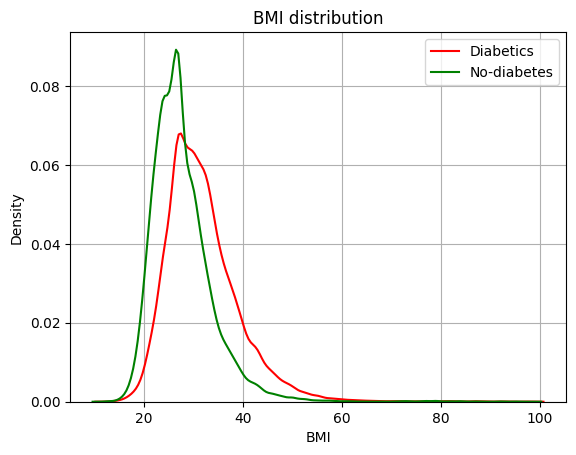

In [8]:
sns.kdeplot(df_yes_bmi,color='red')
sns.kdeplot(df_no_bmi,color='green')
plt.grid()
plt.title('BMI distribution')
plt.legend(['Diabetics', 'No-diabetes'])

In [8]:
print(f"Group 0 count: {len(df_no_bmi)}")
print(f"Group 1 count: {len(df_yes_bmi)}")
u_stat, p_value = mannwhitneyu(df_no_bmi, df_yes_bmi, alternative='two-sided')
print(f"Mann-Whitney U statistic: {u_stat:.4f}")
print(f"P-value: {p_value:.4f}")

if p_value < 0.05:
    print("Reject the null hypothesis — BMI differs significantly between diabetic and non-diabetic groups.")
else:
    print("Fail to reject the null hypothesis — no significant difference in BMI.")


Group 0 count: 35346
Group 1 count: 35346
Mann-Whitney U statistic: 388166232.0000
P-value: 0.0000
Reject the null hypothesis — BMI differs significantly between diabetic and non-diabetic groups.


### 2. Is there a difference in the average number of poor physical health days per month between individuals with and without diabetes?

- **H0 (Null Hypothesis)** - There is no difference in the mean number of poor physical health days between individuals with and without diabetes.
- **Ha(Alternate Hypothesis)** - There is a difference in the mean number of poor physical health days between individuals with and without diabetes.

In [8]:
df_no_ph = df_no['PhysHlth']
df_yes_ph = df_yes['PhysHlth']

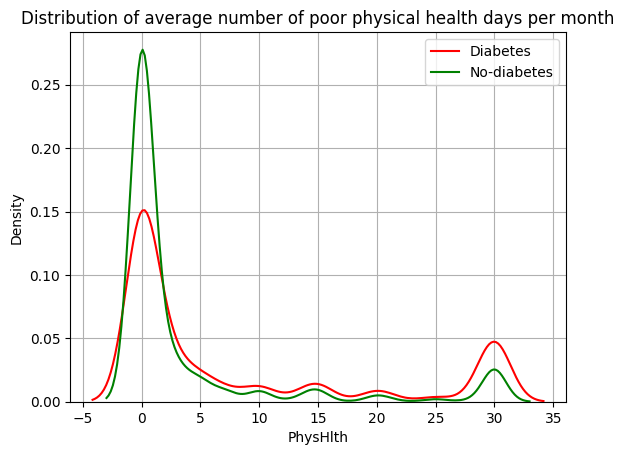

In [9]:
sns.kdeplot(df_yes_ph,color='red')
sns.kdeplot(df_no_ph,color='green')
plt.grid()
plt.title('Distribution of average number of poor physical health days per month')
plt.legend(['Diabetes', 'No-diabetes'])

In [10]:

# Count average days
print('Average days of poor physical health for diabetics is {} and no-diabetics is {} '.format(df_yes_ph.mean(),df_no_ph.mean()))

Average days of poor physical health for diabetics is 7.954478583149437 and no-diabetics is 3.666355457477508 


In [9]:
df_no_ph = df[df['Diabetes_binary'] == 0]['PhysHlth']
df_yes_ph = df[df['Diabetes_binary'] == 1]['PhysHlth']

u_stat, p_value = mannwhitneyu(df_no_ph, df_yes_ph, alternative='two-sided')

print(f"Mann–Whitney U statistic: {u_stat:.4f}")
print(f"P-value: {p_value:.4f}")

if p_value < 0.05:
    print("Reject Null Hypothesis — Diabetics and non-diabetics differ significantly in physical health days.")
else:
    print("Fail to reject Null Hypothesis — No significant difference in physical health days.")


Mann–Whitney U statistic: 484064441.0000
P-value: 0.0000
Reject Null Hypothesis — Diabetics and non-diabetics differ significantly in physical health days.


### 3. Is there an association between having diabetes and having high cholesterol?

- **H0(Null Hypothesis)** - Diabetes status and high cholesterol are independent 
- **Ha(Alternate Hypothesis)** - Diabetes status and high cholesterol are not independent.

In [11]:
contingency= pd.crosstab(df.Diabetes_binary, df.HighChol)
contingency

HighChol,0.0,1.0
Diabetes_binary,,
0.0,21869,13477
1.0,11660,23686


In [12]:
# Run chi-square test
chi2, p, dof, expected = chi2_contingency(contingency)

# Show results
print(f"Chi-square Statistic: {chi2:.4f}")
print(f"P-value: {p:.4f}")
print(f"Degrees of Freedom: {dof}")
print("Expected Frequencies:")
display(pd.DataFrame(expected, index=contingency.index, columns=contingency.columns))

# Interpretation
if p < 0.05:
    print("Reject Null Hypothesis - Diabetes and High Cholesterol are associated.")
else:
    print("Failed to reject Null hypothesis -  No association between Diabetes and High Cholesterol.")

Chi-square Statistic: 5911.8067
P-value: 0.0000
Degrees of Freedom: 1
Expected Frequencies:


HighChol,0.0,1.0
Diabetes_binary,,
0.0,16764.5,18581.5
1.0,16764.5,18581.5


Reject Null Hypothesis - Diabetes and High Cholesterol are associated.


### 4. Do diabetics and non-diabetics have significantly different proportions of high blood pressure?

- **H0(Null Hypothesis)** - Diabetes status and high blood pressure are independent.
- **Ha(Alternate Hypothesis)** - Diabetes status and high blood pressure are not independent

In [13]:
contingency2= pd.crosstab(df.Diabetes_binary, df.HighBP)
contingency2

HighBP,0.0,1.0
Diabetes_binary,,
0.0,22118,13228
1.0,8742,26604


In [14]:
chi2, p, dof, expected = chi2_contingency(contingency)

print(f"Chi-square Statistic: {chi2:.4f}")
print(f"P-value: {p:.4f}")
print(f"Degrees of Freedom: {dof}")
print("Expected Frequencies:")
display(pd.DataFrame(expected, index=contingency.index, columns=contingency.columns))

# Interpretation
if p < 0.05:
    print("Reject Null Hypotheis - Diabetes status is associated with high blood pressure.")
else:
    print("Failed to Reject Null Hypotheis - No association between diabetes status and high blood pressure.")

Chi-square Statistic: 5911.8067
P-value: 0.0000
Degrees of Freedom: 1
Expected Frequencies:


HighChol,0.0,1.0
Diabetes_binary,,
0.0,16764.5,18581.5
1.0,16764.5,18581.5


Reject Null Hypotheis - Diabetes status is associated with high blood pressure.


### Trying to find association on other binary Features with diabetes status.


In [10]:
binary_features = [
    'Smoker', 'HvyAlcoholConsump', 'PhysActivity', 'DiffWalk', 'CholCheck',
    'Stroke', 'HeartDiseaseorAttack', 'Fruits', 'Veggies', 'AnyHealthcare',
    'NoDocbcCost', 'GenHlth', 'Sex'
]

for feature in binary_features:
    print(f"\n Feature: {feature}")

    contingency = pd.crosstab(df[feature], df['Diabetes_binary'])
    chi2, p, dof, expected = chi2_contingency(contingency)

    print("Null Hypothesis (H₀):")
    print(f"   There is no association between '{feature}' and diabetes status.")
    print("Alternative Hypothesis (H₁):")
    print(f"   There is a significant association between '{feature}' and diabetes status.")

    print(f"\nChi² Statistic = {chi2:.4f}")
    print(f"P-value        = {p:.4f}")
    print(f"Degrees of Freedom = {dof}")
    
    if p < 0.05:
        print(" Reject the null hypothesis → Significant association found.")
    else:
        print("Fail to reject the null hypothesis → No significant association.")

    print("-" * 60)



 Feature: Smoker
Null Hypothesis (H₀):
   There is no association between 'Smoker' and diabetes status.
Alternative Hypothesis (H₁):
   There is a significant association between 'Smoker' and diabetes status.

Chi² Statistic = 522.4811
P-value        = 0.0000
Degrees of Freedom = 1
 Reject the null hypothesis → Significant association found.
------------------------------------------------------------

 Feature: HvyAlcoholConsump
Null Hypothesis (H₀):
   There is no association between 'HvyAlcoholConsump' and diabetes status.
Alternative Hypothesis (H₁):
   There is a significant association between 'HvyAlcoholConsump' and diabetes status.

Chi² Statistic = 635.0865
P-value        = 0.0000
Degrees of Freedom = 1
 Reject the null hypothesis → Significant association found.
------------------------------------------------------------

 Feature: PhysActivity
Null Hypothesis (H₀):
   There is no association between 'PhysActivity' and diabetes status.
Alternative Hypothesis (H₁):
   There 

In [11]:
for feature in binary_features:
    print(f"\nFeature: {feature}")
    
    # Get actual counts
    table = pd.crosstab(df[feature], df['Diabetes_binary'])
    print("Contingency Table:")
    print(table)

    # Chi-square test
    chi2, p, dof, expected = chi2_contingency(table)

    # Calculate Cramér's V
    n = table.sum().sum()  # total sample size
    cramers_v = np.sqrt(chi2 / (n * (min(table.shape) - 1)))

    # Show proportions
    prop = table.div(table.sum(axis=0), axis=1)
    print("\nProportions by Diabetes Status (columns):")
    print(prop)

    print(f"\nChi² = {chi2:.2f}, p = {p:.4g}, df = {dof}")
    print(f"Cramér's V = {cramers_v:.4f}  ({'Small' if cramers_v<0.3 else 'Medium' if cramers_v<0.5 else 'Large'} effect)")
    print("→", "Reject H₀" if p < 0.05 else "Fail to reject H₀")
    print("-" * 60)



Feature: Smoker
Contingency Table:
Diabetes_binary    0.0    1.0
Smoker                       
0.0              20065  17029
1.0              15281  18317

Proportions by Diabetes Status (columns):
Diabetes_binary       0.0      1.0
Smoker                            
0.0              0.567674  0.48178
1.0              0.432326  0.51822

Chi² = 522.48, p = 1.221e-115, df = 1
Cramér's V = 0.0860  (Small effect)
→ Reject H₀
------------------------------------------------------------

Feature: HvyAlcoholConsump
Contingency Table:
Diabetes_binary      0.0    1.0
HvyAlcoholConsump              
0.0                33158  34514
1.0                 2188    832

Proportions by Diabetes Status (columns):
Diabetes_binary         0.0       1.0
HvyAlcoholConsump                    
0.0                0.938098  0.976461
1.0                0.061902  0.023539

Chi² = 635.09, p = 3.913e-140, df = 1
Cramér's V = 0.0948  (Small effect)
→ Reject H₀
--------------------------------------------------------